In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import Counter

data_dir = "../data/openfake"

real: 50000장
fake: 78444장
real:fake 비율 = 1:1.57


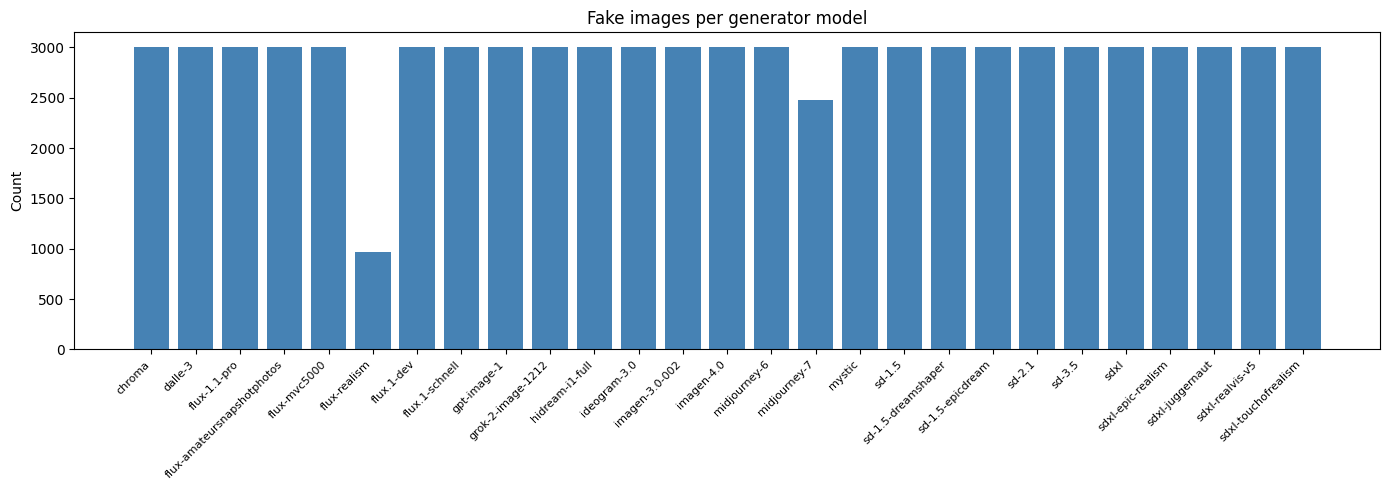

In [2]:
real_files = os.listdir(f"{data_dir}/real")
fake_files = os.listdir(f"{data_dir}/fake")

fake_counts = {}
for fname in fake_files:
    model_name = "_".join(fname.split("_")[:-1])
    fake_counts[model_name] = fake_counts.get(model_name, 0) + 1

print(f"real: {len(real_files)}장")
print(f"fake: {len(fake_files)}장")
print(f"real:fake 비율 = 1:{len(fake_files)/len(real_files):.2f}")

# 모델별 분포 시각화
plt.figure(figsize=(14, 5))
models = sorted(fake_counts.keys())
counts = [fake_counts[m] for m in models]
plt.bar(models, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title("Fake images per generator model")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

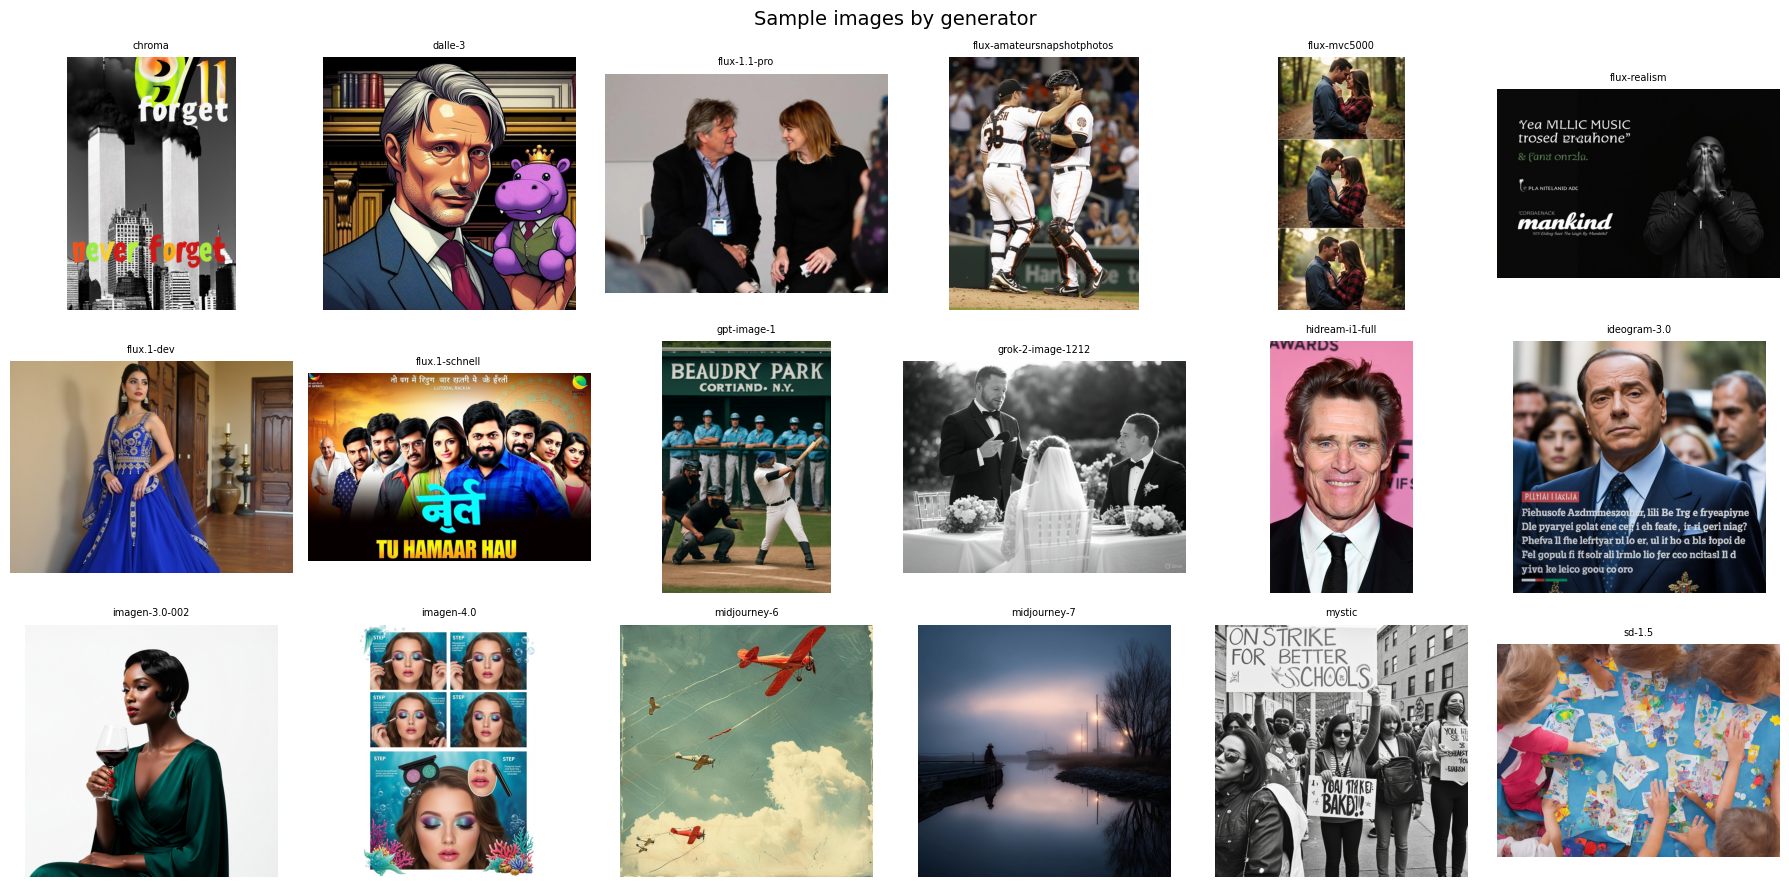

In [3]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Sample images by generator", fontsize=14)

sample_models = sorted(fake_counts.keys())[:18]

for idx, model in enumerate(sample_models):
    row, col = idx // 6, idx % 6
    model_files = [f for f in fake_files if f.startswith(model + "_")]
    sample_file = model_files[0]
    img = Image.open(f"{data_dir}/fake/{sample_file}")
    axes[row][col].imshow(img)
    axes[row][col].set_title(model, fontsize=7)
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()

평균 해상도: 770 x 756
최소: 112 x 102
최대: 2500 x 1668


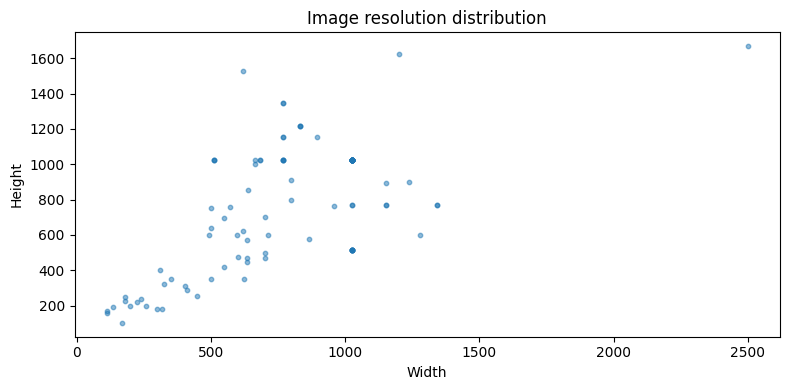

In [4]:
widths, heights = [], []

# 각 모델당 10장씩만 샘플링
for model in list(fake_counts.keys())[:5]:
    model_files = [f for f in fake_files if f.startswith(model + "_")][:10]
    for fname in model_files:
        img = Image.open(f"{data_dir}/fake/{fname}")
        widths.append(img.width)
        heights.append(img.height)

# real도 10장
for fname in real_files[:50]:
    img = Image.open(f"{data_dir}/real/{fname}")
    widths.append(img.width)
    heights.append(img.height)

print(f"평균 해상도: {np.mean(widths):.0f} x {np.mean(heights):.0f}")
print(f"최소: {min(widths)} x {min(heights)}")
print(f"최대: {max(widths)} x {max(heights)}")

plt.figure(figsize=(8, 4))
plt.scatter(widths, heights, alpha=0.5, s=10)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image resolution distribution")
plt.tight_layout()
plt.show()